In [5]:
import os
import sys
sys.path.append('src/FoKL')

import FoKLRoutines
import numpy as np


Currently training model...


Done! Please close the figure to continue.


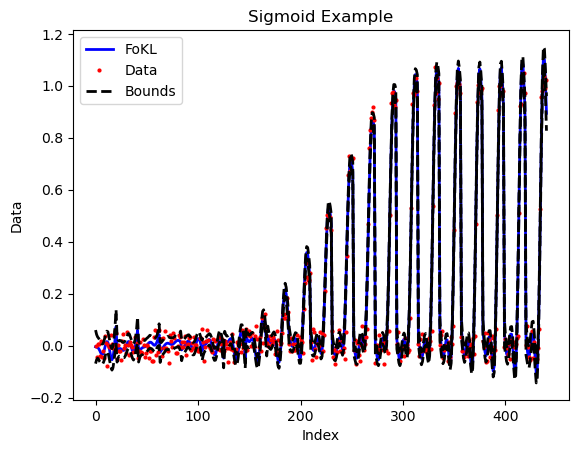


The 'coverage3' method returned:
    RMSE = 7.2640003512419e-05


In [6]:
# Known dataset:
x_grid = np.loadtxt('src/FoKL/x.csv', dtype=float, delimiter=',')  # first input
y_grid = np.loadtxt('src/FoKL/y.csv', dtype=float, delimiter=',')  # second input
z_grid = np.loadtxt('src/FoKL/z.csv', dtype=float, delimiter=',')  # data

# Some formatting of dataset (i.e., reshaping grid matrices into vectors via fortran index order):
m, n = np.shape(x_grid) # == np.shape(y_grid) == np.shape(z_grid) == dimensions of grid
x = np.reshape(x_grid, (m * n, 1), order='F')
y = np.reshape(y_grid, (m * n, 1), order='F')
z = np.reshape(z_grid, (m * n, 1), order='F')

# Initializing FoKL model with some user-defined hyperparameters (leaving others blank for default values) and
# turning off user-warnings (i.e., warnings from FoKL) since working example requires no troubleshooting:
model = FoKLRoutines.FoKL(a=9, b=0.01, atau=3, btau=4000, aic=False, UserWarnings=False, ConsoleOutput=False)

# Running emulator routine (i.e., 'fit') to train model:
print("\nCurrently training model...\n")
betas, mtx, ev = model.fit([x, y], z, clean=True)

# Evaluating and visualizing predicted values of data as a function of all inputs (train set plus test set):
print("\nDone! Please close the figure to continue.")
_, _, rmse = model.coverage3(plot=True, title='Sigmoid Example')

# Post-processing:
print(f"\nThe 'coverage3' method returned:\n    RMSE = {rmse}")